# UTS - Kasus 2: MNIST (Image)

## 0. Setup & Reproducibility
Tahap ini menyiapkan dependensi, seed, dan fungsi utilitas agar eksperimen image classification konsisten.

In [1]:
# Tahap setup: validasi environment venv dan import library yang dibutuhkan.
# Jalankan `pip install -r requirements.txt` terlebih dahulu sebelum membuka notebook ini.
required_modules = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'skimage', 'sklearn', 'torch']
missing_modules = []
for module_name in required_modules:
    try:
        __import__(module_name)
    except ModuleNotFoundError:
        missing_modules.append(module_name)

if missing_modules:
    raise ModuleNotFoundError(
        'Ada package yang belum terpasang: ' + ', '.join(missing_modules) +
        '. Jalankan `pip install -r requirements.txt` pada environment aktif.'
    )

# Tahap setup: import library untuk pengolahan citra, model klasik, dan CNN.
import time
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')


In [2]:
# Tahap reproducibility: menetapkan seed agar hasil train/valid konsisten.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CONFIG = {'seed': SEED, 'test_size': 0.2, 'val_size': 0.2}
print('Konfigurasi aktif:', CONFIG)


Konfigurasi aktif: {'seed': 42, 'test_size': 0.2, 'val_size': 0.2}


## 1. EDA
Tahap ini mengecek struktur data MNIST, distribusi label, dan menampilkan contoh citra digit.

In [3]:
# Tahap EDA: membuat cache lokal lalu mengunduh data MNIST jika file belum tersedia.
# Format umum: kolom pertama label, sisanya pixel0..pixel783.
import urllib.request

BASE_DIR = Path.cwd()
CACHE_DIR = BASE_DIR / '.cache' / 'datasets' / 'mnist'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def download_if_missing(urls, out_path):
    if out_path.exists():
        return out_path
    for url in urls:
        try:
            print(f'Download: {url}')
            urllib.request.urlretrieve(url, out_path)
            return out_path
        except Exception as e:
            print(f'Gagal dari {url}: {e}')
    return None

train_urls = [
    'https://raw.githubusercontent.com/wehrley/Kaggle-Digit-Recognizer/master/train.csv'
]
cached_train = download_if_missing(train_urls, CACHE_DIR / 'train.csv')

TRAIN_CANDIDATES = [
    cached_train,
    BASE_DIR / 'data' / 'mnist' / 'train.csv',
    BASE_DIR / 'datasets' / 'mnist' / 'train.csv',
    BASE_DIR / 'train.csv',
]
TRAIN_PATH = next((p for p in TRAIN_CANDIDATES if (p is not None and p.exists())), None)
if TRAIN_PATH is None:
    raise FileNotFoundError(
        'File MNIST train.csv tidak ditemukan. Pastikan internet aktif atau simpan train.csv di data/mnist/.'
    )

df = pd.read_csv(TRAIN_PATH)
print('Path train:', TRAIN_PATH)
print('Ukuran data:', df.shape)
df.head()


Path train: c:\Users\muham\Kuliah\Ekstensi\Semester Genap 25-26\Pengantar Deep Learning\UTS\notebooks\.cache\datasets\mnist\train.csv
Ukuran data: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

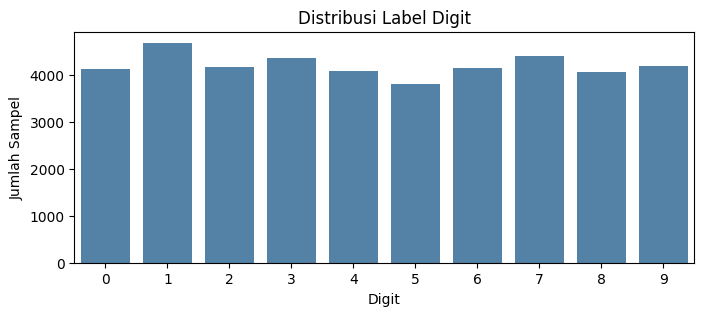

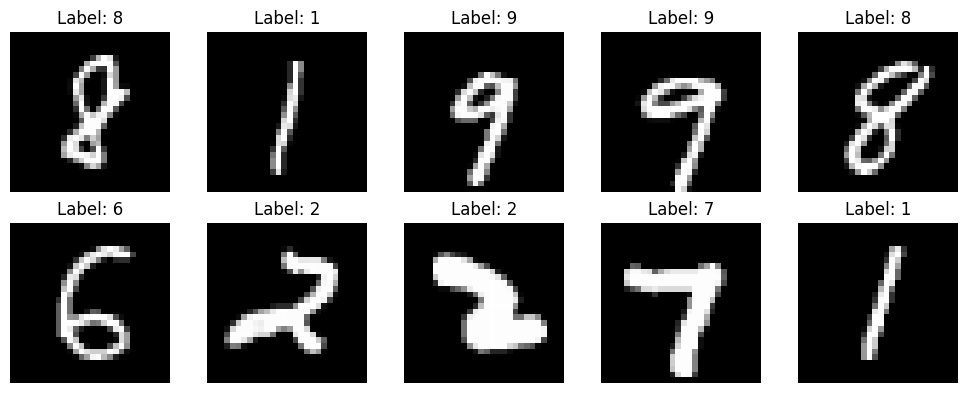

In [4]:
# Tahap EDA: melihat distribusi kelas dan contoh visual digit.
label_counts = df['label'].value_counts().sort_index()
display(label_counts)

plt.figure(figsize=(8, 3))
sns.barplot(x=label_counts.index, y=label_counts.values, color='steelblue')
plt.title('Distribusi Label Digit')
plt.xlabel('Digit')
plt.ylabel('Jumlah Sampel')
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
samples = df.sample(10, random_state=SEED)
for ax, (_, row) in zip(axes.ravel(), samples.iterrows()):
    img = row.drop('label').to_numpy().reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {int(row['label'])}")
    ax.axis('off')
plt.tight_layout()
plt.show()


## 2. Preprocessing
Tahap ini melakukan split data konsisten, normalisasi piksel, dan persiapan fitur untuk baseline klasik serta CNN.

In [5]:
# Tahap preprocessing: memisahkan fitur dan target lalu split train/val/test.
X = df.drop(columns=['label']).to_numpy()
y = df['label'].to_numpy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=CONFIG['val_size'], random_state=SEED, stratify=y_train_full
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (26880, 784) Val: (6720, 784) Test: (8400, 784)


In [6]:
# Tahap preprocessing: menyiapkan data untuk CNN PyTorch (normalisasi + reshape channel).
X_train_cnn = (X_train / 255.0).reshape(-1, 1, 28, 28).astype(np.float32)
X_val_cnn = (X_val / 255.0).reshape(-1, 1, 28, 28).astype(np.float32)
X_test_cnn = (X_test / 255.0).reshape(-1, 1, 28, 28).astype(np.float32)

print('Shape input CNN:', X_train_cnn.shape)


Shape input CNN: (26880, 1, 28, 28)


## 3. Baseline ML
Tahap ini melatih minimal 2 kombinasi metode konvensional, misalnya HOG+SVM dan PCA+KNN.

In [7]:
# Tahap baseline ML: ekstraksi fitur HOG lalu klasifikasi dengan Linear SVM.
from joblib import Parallel, delayed
from skimage.feature import hog

def extract_single_hog(img):
    img2d = img.reshape(28, 28)
    return hog(img2d, pixels_per_cell=(4, 4), cells_per_block=(2, 2), feature_vector=True)

def extract_hog_features(flat_images):
    feats = Parallel(n_jobs=-1)(delayed(extract_single_hog)(img) for img in flat_images)
    return np.array(feats)

start = time.perf_counter()
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
svm = Pipeline([('scaler', StandardScaler()), ('clf', LinearSVC(random_state=SEED))])
svm.fit(X_train_hog, y_train)
svm_time = time.perf_counter() - start
svm_val_pred = svm.predict(X_val_hog)
svm_acc = accuracy_score(y_val, svm_val_pred)
print('HOG+LinearSVM val accuracy:', round(svm_acc, 4))


HOG+LinearSVM val accuracy: 0.9682


In [8]:
# Tahap baseline ML: reduksi dimensi PCA lalu klasifikasi KNN sebagai baseline kedua.
pca_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=SEED)),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

start = time.perf_counter()
pca_knn.fit(X_train, y_train)
knn_time = time.perf_counter() - start
knn_val_pred = pca_knn.predict(X_val)
knn_acc = accuracy_score(y_val, knn_val_pred)
print('PCA+KNN val accuracy:', round(knn_acc, 4))


PCA+KNN val accuracy: 0.9374


## 4. Deep Learning
Tahap ini membangun dan melatih CNN sederhana sebagai pendekatan deep learning utama untuk data image.

In [9]:
# Tahap deep learning: mendefinisikan arsitektur CNN PyTorch dan melatih model.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = TensorDataset(torch.from_numpy(X_train_cnn), torch.from_numpy(y_train.astype(np.int64)))
val_ds = TensorDataset(torch.from_numpy(X_val_cnn), torch.from_numpy(y_val.astype(np.int64)))
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

best_val_loss = float('inf')
best_state = None
patience = 5
wait = 0
max_epochs = 20

start = time.perf_counter()
for epoch in range(max_epochs):
    cnn.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = cnn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    cnn.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = cnn(xb)
            vloss = criterion(logits, yb)
            val_losses.append(vloss.item())

    avg_val_loss = float(np.mean(val_losses))
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in cnn.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

if best_state is not None:
    cnn.load_state_dict(best_state)

cnn_time = time.perf_counter() - start
print('Training CNN PyTorch selesai, durasi (detik):', round(cnn_time, 2))


Training CNN PyTorch selesai, durasi (detik): 132.61


## 5. Evaluasi
Tahap ini membandingkan metrik utama, confusion matrix, serta waktu training/inferensi antar pendekatan.

In [10]:
# Tahap evaluasi: menghitung metrik untuk semua model pada test set.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cnn.eval()
with torch.no_grad():
    test_logits = cnn(torch.from_numpy(X_test_cnn).to(device)).cpu().numpy()
cnn_test_pred = np.argmax(test_logits, axis=1)

X_test_hog = extract_hog_features(X_test)
test_preds = {
    'HOG+LinearSVM': svm.predict(X_test_hog),
    'PCA+KNN': pca_knn.predict(X_test),
    'CNN': cnn_test_pred
}

eval_results = []
for name, pred in test_preds.items():
    eval_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, average='macro'),
        'recall': recall_score(y_test, pred, average='macro'),
        'f1_score': f1_score(y_test, pred, average='macro')
    })
comparison_df = pd.DataFrame(eval_results)
display(comparison_df.sort_values('accuracy', ascending=False))


,model,accuracy,precision,recall,f1_score
2,CNN,0.988452,0.988419,0.988306,0.988345
0,HOG+LinearSVM,0.967262,0.967094,0.966884,0.966937
1,PCA+KNN,0.937976,0.938201,0.937007,0.937176


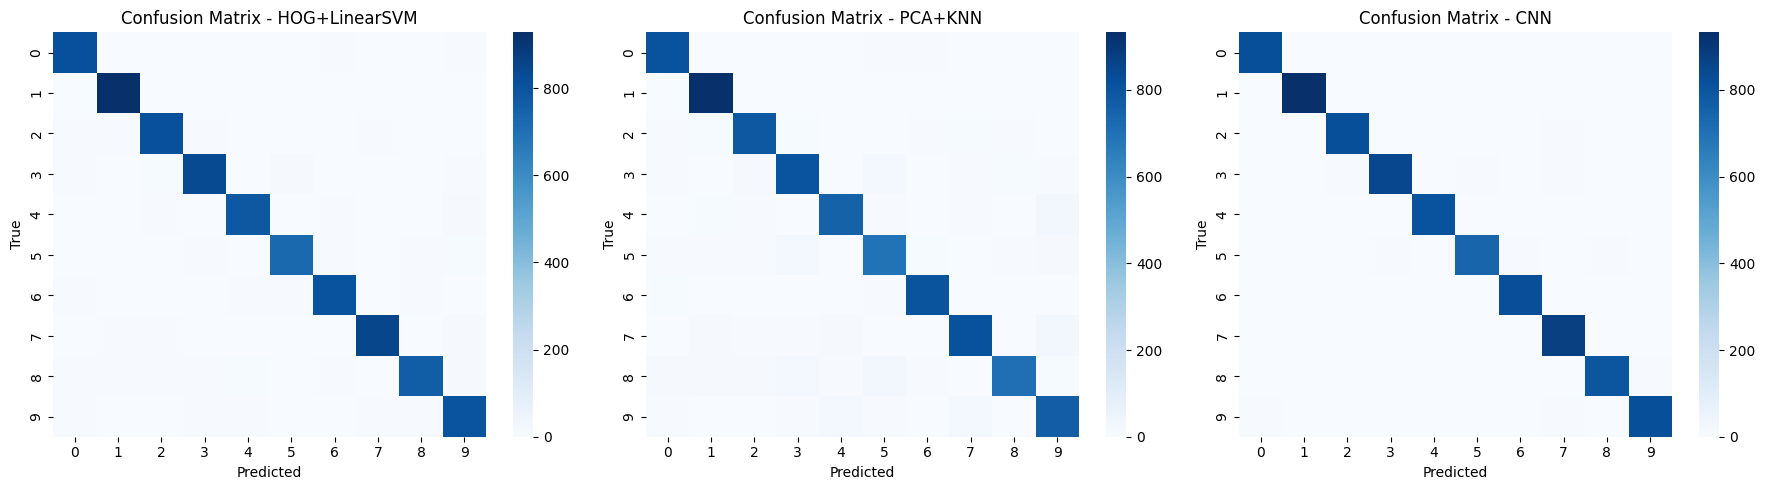

In [11]:
# Tahap evaluasi: menampilkan confusion matrix untuk semua model (side-by-side).
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pred) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()


## 6. Error Analysis
Tahap ini menampilkan contoh digit yang salah diprediksi dan membandingkan pola kesalahan antar model.

Total kesalahan CNN: 97 dari 8400 gambar test


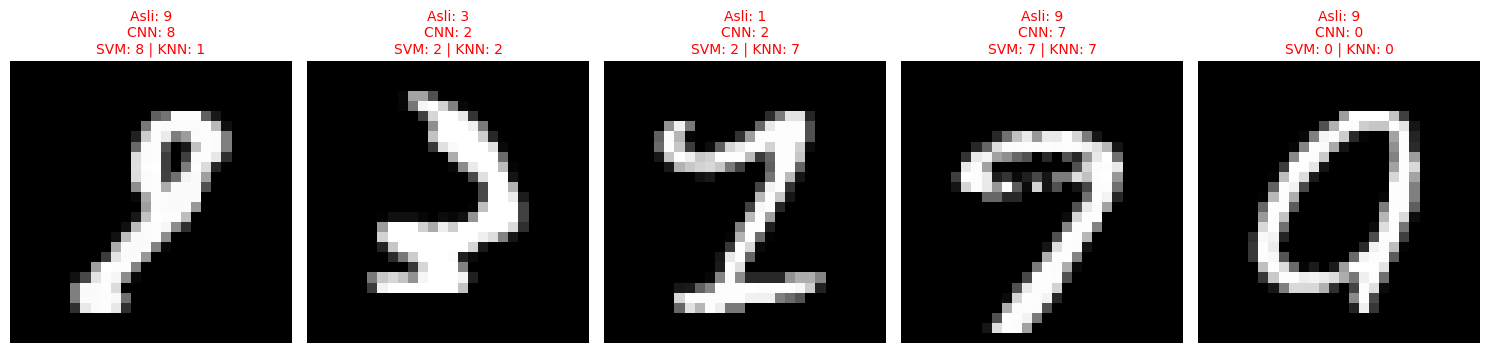


Total gambar yang gagal ditebak oleh KETIGA model: 50


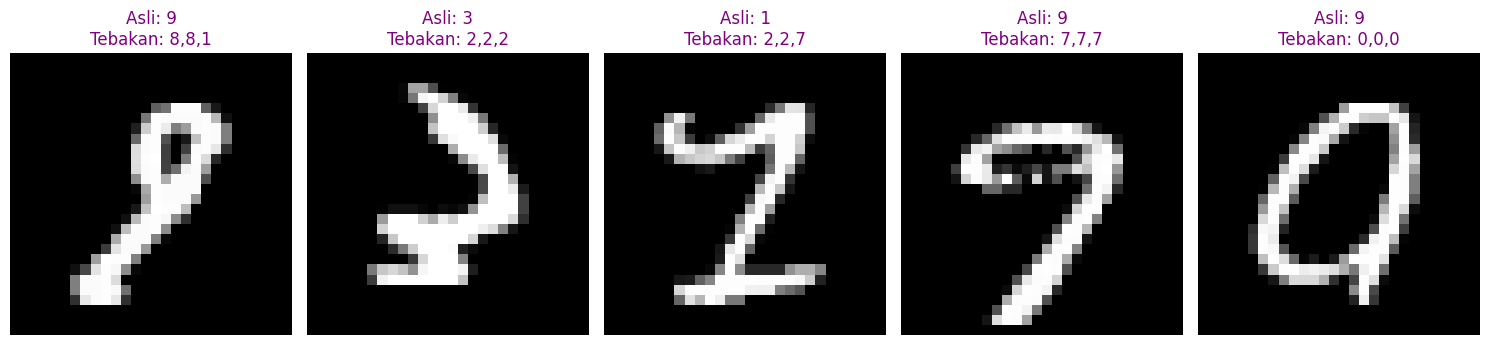

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Kumpulkan hasil prediksi
actuals = y_test if isinstance(y_test, np.ndarray) else y_test.values
preds_svm = test_preds['HOG+LinearSVM']
preds_knn = test_preds['PCA+KNN']
preds_cnn = test_preds['CNN']

# Temukan indeks di mana CNN salah
cnn_errors_idx = np.where(actuals != preds_cnn)[0]

print(f"Total kesalahan CNN: {len(cnn_errors_idx)} dari {len(actuals)} gambar test")

if len(cnn_errors_idx) > 0:
    # Tampilkan 5 gambar pertama yang salah ditebak CNN
    num_images = min(5, len(cnn_errors_idx))
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
    if num_images == 1:
        axes = [axes]
        
    for i, idx in enumerate(cnn_errors_idx[:num_images]):
        # Ambil gambar asli (28x28) dari X_test
        img = X_test.iloc[idx].values.reshape(28, 28) if hasattr(X_test, 'iloc') else X_test[idx].reshape(28, 28)
        
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        
        # Judul dengan perbandingan ke-3 model
        title = (f"Asli: {actuals[idx]}\n"
                 f"CNN: {preds_cnn[idx]}\n"
                 f"SVM: {preds_svm[idx]} | KNN: {preds_knn[idx]}")
        
        # Highlight title dengan warna merah
        axes[i].set_title(title, fontsize=10, color='red')
        
    plt.tight_layout()
    plt.show()
else:
    print("CNN memprediksi semua gambar dengan benar (100% akurasi) di data uji ini!")

# Cari hard examples (salah di semua model)
all_errors_idx = np.where((actuals != preds_svm) & (actuals != preds_knn) & (actuals != preds_cnn))[0]
print(f"\nTotal gambar yang gagal ditebak oleh KETIGA model: {len(all_errors_idx)}")
if len(all_errors_idx) > 0:
    num_images = min(5, len(all_errors_idx))
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
    if num_images == 1: axes = [axes]
    for i, idx in enumerate(all_errors_idx[:num_images]):
        img = X_test.iloc[idx].values.reshape(28, 28) if hasattr(X_test, 'iloc') else X_test[idx].reshape(28, 28)
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Asli: {actuals[idx]}\nTebakan: {preds_cnn[idx]},{preds_svm[idx]},{preds_knn[idx]}", color='purple')
    plt.tight_layout()
    plt.show()
